# Chest X-Ray (CXR) Lung Segmentation

This notebook shows how to:
* Load the CXR Lung Segmentation dataset from Kaggle in PyHealth
* Define a segmentation task and process images into tensors

Note: This dataset expects 'CXR_png' and 'masks' subdirectories in the root folder.

In [1]:
import os
import matplotlib.pyplot as plt
import torch
import numpy as np

from pyhealth.utils import set_seed
set_seed(42)

from pyhealth.datasets.cxr_segmentation import CXRSegmentationDataset
from pyhealth.tasks.cxr_image_segmentation import CXRSegmentationTask

root = "/mnt/d/cxr/Lung Segmentation"
root = "/tmp/cxr"

print("--- Downloading & loading dataset into memory ---")
print("--- The dataset is ~10GB, so download can take a few minutes. ---")
dataset = CXRSegmentationDataset(root=root, dev=False, download=True)
dataset.stats()

--- Downloading & loading dataset into memory ---
--- The dataset is ~10GB, so download can take a few minutes. ---


Extracting /tmp/cxr/chest-xray-masks-and-labels.zip to /tmp/cxr...


Moving CXR_png from /tmp/cxr/Lung Segmentation to /tmp/cxr...
Moving masks from /tmp/cxr/Lung Segmentation to /tmp/cxr...
Removing nested directory /tmp/cxr/Lung Segmentation...
Removing duplicate data at  /tmp/cxr/data...
Cleaning up zip file...
Download and extraction complete.
Scanning directory /tmp/cxr/CXR_png for dataset...
Generated metadata with 704 samples: /tmp/cxr/cxr_segmentation-pyhealth.csv
Initializing cxr_segmentation dataset from /tmp/cxr (dev mode: False)
No cache_dir provided. Using default cache dir: /home/eliothsu/.cache/pyhealth/6032da00-91d5-5713-840f-ef83dfd3afdd
Found cached event dataframe: /home/eliothsu/.cache/pyhealth/6032da00-91d5-5713-840f-ef83dfd3afdd/global_event_df.parquet
Dataset: cxr_segmentation
Dev mode: False
Number of patients: 704
Number of events: 704


## Define and Set Task

The task transforms the patient data into model-ready (image, mask) samples. 
By default, the `ImageProcessor` resizes images to 224x224 and converts them to Tensors.

In [2]:
# Depending on the single-threaded speed of your CPU, this will take ~3m40s (benchmarked on i5-13600k)
samples = dataset.set_task(CXRSegmentationTask())

print(f"Number of samples: {len(samples)}")

Setting task CXRSegmentationTask for cxr_segmentation base dataset...
Task cache paths: task_df=/home/eliothsu/.cache/pyhealth/6032da00-91d5-5713-840f-ef83dfd3afdd/tasks/CXRSegmentationTask_e98a315b-48db-5630-92fa-e950969d33cc/task_df.ld, samples=/home/eliothsu/.cache/pyhealth/6032da00-91d5-5713-840f-ef83dfd3afdd/tasks/CXRSegmentationTask_e98a315b-48db-5630-92fa-e950969d33cc/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached task dataframe at /home/eliothsu/.cache/pyhealth/6032da00-91d5-5713-840f-ef83dfd3afdd/tasks/CXRSegmentationTask_e98a315b-48db-5630-92fa-e950969d33cc/task_df.ld, skipping task transformation.
Fitting processors on the dataset...
Processing samples and saving to /home/eliothsu/.cache/pyhealth/6032da00-91d5-5713-840f-ef83dfd3afdd/tasks/CXRSegmentationTask_e98a315b-48db-5630-92fa-e950969d33cc/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld...
Applying processors on data with 20 workers...
Detected Jupyter notebook environment, setting num_workers to 1
Single 

  0%|                                                                                         | 0/704 [00:00<?, ?it/s]

Rank 0 inferred the following `['tensor', 'tensor', 'str']` data format.


100%|███████████████████████████████████████████████████████████████████████████████| 704/704 [00:54<00:00, 12.99it/s]

Worker 0 finished processing samples.
Cached processed samples to /home/eliothsu/.cache/pyhealth/6032da00-91d5-5713-840f-ef83dfd3afdd/tasks/CXRSegmentationTask_e98a315b-48db-5630-92fa-e950969d33cc/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Number of samples: 704


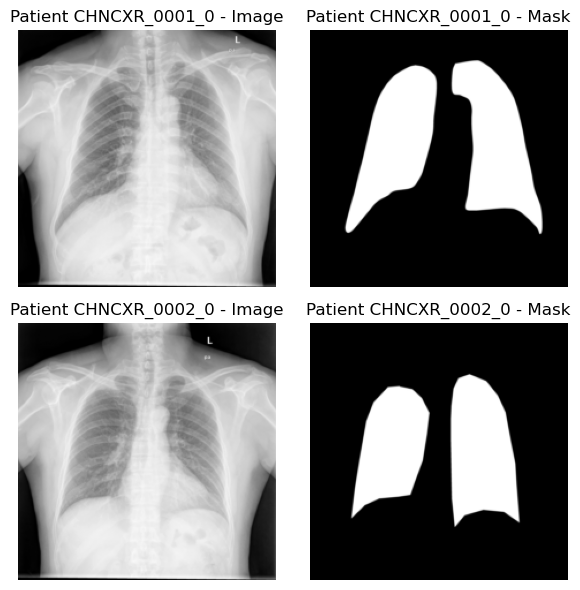

In [3]:
n_display = 2
fig, axes = plt.subplots(n_display, 2, figsize=(6, 3 * n_display))

for i in range(min(n_display, len(samples))):
    sample = samples[i]
    img = sample["image"]
    mask = sample["mask"]
    
    # Convert torch Tensors to numpy for plotting: (C, H, W) -> (H, W, C)
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).numpy()
    if isinstance(mask, torch.Tensor):
        mask = mask.squeeze().numpy()

    axes[i, 0].imshow(img, cmap="gray")
    axes[i, 0].set_title(f"Patient {sample['patient_id']} - Image")

    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"Patient {sample['patient_id']} - Mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## Model Implementation: U-Net

We initialize the U-Net model. It automatically infers the number of input channels from the dataset.

In [4]:
from pyhealth.models.unet import UNet

device = "cuda" if torch.cuda.is_available() else "cpu"
# Use 'samples' (SampleDataset) which contains the schema, instead of 'dataset' (BaseDataset)
model = UNet(samples, n_classes=1)
model.to(device)

print(f"Model initialized on {device}")
print(f"Input channels: {model.n_channels}")
print(f"Output classes: {model.n_classes}")

Model initialized on cuda
Input channels: 1
Output classes: 1


## Training

Train using Dice + Cross-Entropy loss, and monitor the Dice coefficient.

In [5]:
from pyhealth.datasets import split_by_patient, get_dataloader
from pyhealth.trainer import Trainer
from pyhealth.metrics import segmentation_metrics_fn

train_ds, val_ds, test_ds = split_by_patient(samples, [0.8, 0.1, 0.1])
train_loader = get_dataloader(train_ds, batch_size=8, shuffle=True)
val_loader = get_dataloader(val_ds, batch_size=8, shuffle=False)
test_loader = get_dataloader(test_ds, batch_size=8, shuffle=False)

trainer = Trainer(
    model=model,
    metrics=["dice", "iou"],
    device=device,
)

UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (2): LeakyReLU(negative_slope=0.01, inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    )
    (shortcut): Sequential(
      (0): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    )
  )
  (downs): ModuleList(
    (0): DoubleConv(
      (double_conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (2): LeakyReLU(negative_slope

In [6]:
trainer.train(
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    epochs=20,
    optimizer_class=torch.optim.AdamW,
    optimizer_params={"lr": 1e-4},
    weight_decay=1e-5,
    monitor="dice",
)

Training:
Batch size: 8
Optimizer: <class 'torch.optim.adamw.AdamW'>
Optimizer params: {'lr': 0.0001}
Weight decay: 1e-05
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x79749da82490>
Monitor: dice
Monitor criterion: max
Epochs: 20
Patience: None



Epoch 0 / 20:   0%|          | 0/71 [00:00<?, ?it/s]

--- Train epoch-0, step-71 ---
loss: 0.4671


Evaluation: 100%|███████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 49.00it/s]


--- Eval epoch-0, step-71 ---
dice: 0.9427
iou: 0.8915
loss: 0.2719
New best dice score (0.9427) at epoch-0, step-71



...

--- Eval epoch-18, step-1349 ---
dice: 0.9612
iou: 0.9253
loss: 0.1233
New best dice score (0.9612) at epoch-18, step-1349


Epoch 19 / 20:   0%|          | 0/71 [00:00<?, ?it/s]

--- Train epoch-19, step-1420 ---
loss: 0.0486


Evaluation: 100%|███████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 61.65it/s]

--- Eval epoch-19, step-1420 ---
dice: 0.9600
iou: 0.9231
loss: 0.1285
Loaded best model


## Evaluation

Finally, we evaluate the model on the test set and visualize some predictions.

Evaluation: 100%|███████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 20.74it/s]


Test results: {'dice': np.float32(0.96492445), 'iou': np.float32(0.9322262), 'loss': 0.10874691853920619}


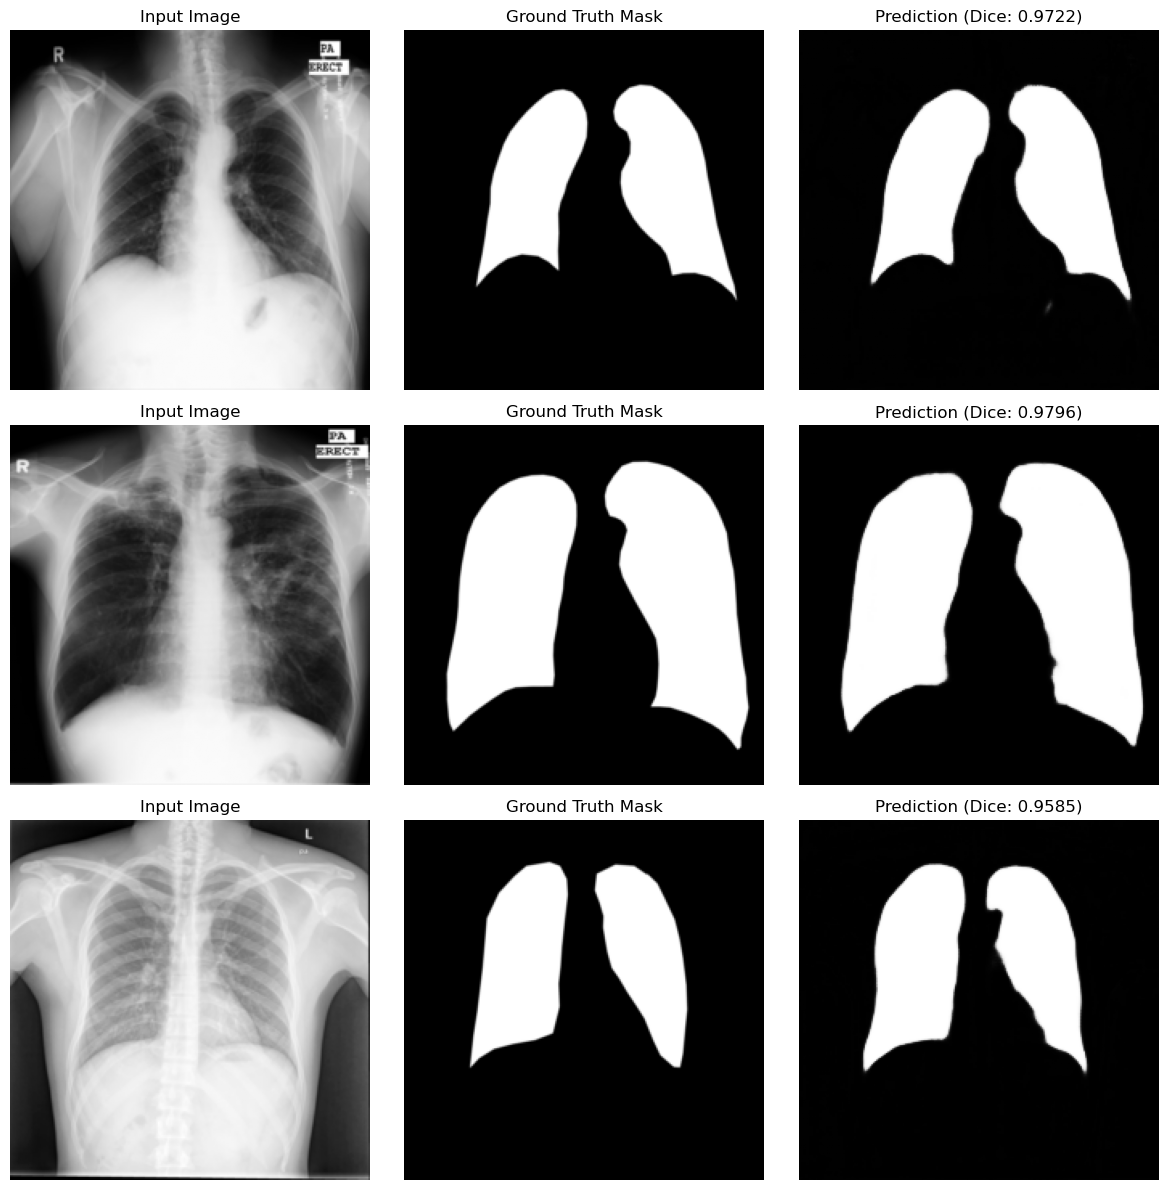

In [7]:
test_results = trainer.evaluate(test_loader)
print(f"Test results: {test_results}")

# Visualize some predictions from the test set
batch = next(iter(test_loader))
model.eval()
with torch.no_grad():
    output = model(**batch)

n_display = 3
plt.figure(figsize=(12, 4 * n_display))
for i in range(n_display):
    plt.subplot(n_display, 3, i * 3 + 1)
    plt.imshow(batch['image'][i].cpu().permute(1, 2, 0).numpy(), cmap='gray')
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(n_display, 3, i * 3 + 2)
    plt.imshow(batch['mask'][i].cpu().squeeze().numpy(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(n_display, 3, i * 3 + 3)
    plt.imshow(output['y_prob'][i].cpu().squeeze().numpy(), cmap='gray')
    plt.title(f"Prediction (Dice: {segmentation_metrics_fn(batch['mask'][i:i+1].cpu().numpy(), output['y_prob'][i:i+1].detach().cpu().numpy())['dice']:.4f})")
    plt.axis("off")

plt.tight_layout()
plt.show()